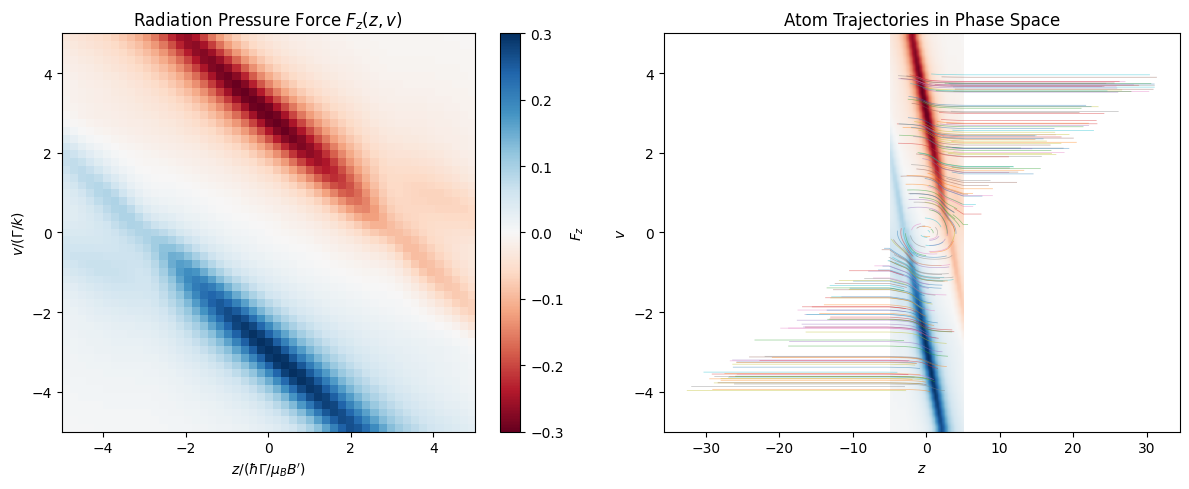

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pylcp
from scipy.interpolate import RegularGridInterpolator

x = np.arange(-5, 5.1, 0.2)
v = np.arange(-5, 5.1, 0.2)
X, V = np.meshgrid(x, v)

det = -3.0     
alpha = 1.0        
s = 2.0         
mass = 1.0          

laserBeams = pylcp.conventional3DMOTBeams(delta=det, s=s,
                                          beam_type=pylcp.infinitePlaneWaveBeam)
magField = pylcp.quadrupoleMagneticField(alpha)


Fl, Fu = 1, 2   # Choose one hyperfine pair

Hg, Bgq = pylcp.hamiltonians.singleF(F=Fl, gF=0, muB=1)
He, Beq = pylcp.hamiltonians.singleF(F=Fu, gF=1/Fu, muB=1)
dijq = pylcp.hamiltonians.dqij_two_bare_hyperfine(Fl, Fu)
hamiltonian = pylcp.hamiltonian(Hg, He, Bgq, Beq, dijq)

rateeq = pylcp.rateeq(laserBeams, magField, hamiltonian,
                      svd_eps=1e-10, include_mag_forces=False)

rateeq.generate_force_profile(
    [np.zeros(X.shape), np.zeros(X.shape), X],
    [np.zeros(V.shape), np.zeros(V.shape), V],
    name='Fz')

Fz = rateeq.profile['Fz'].F[2]   # Force along z

fig, ax = plt.subplots(1, 2, figsize=(12,5))
im = ax[0].imshow(
    Fz,
    extent=(np.amin(X[0, :]), np.amax(X[0, :]),
            np.amin(V[:, 0]), np.amax(V[:, 0])),
    origin='lower',
    aspect='auto',
    vmin=-0.3, vmax=0.3,
    cmap='RdBu'
)
ax[0].set_title(r"Radiation Pressure Force $F_z(z,v)$")
ax[0].set_xlabel(r"$z/(\hbar\Gamma/\mu_B B')$")
ax[0].set_ylabel(r"$v/(\Gamma/k)$")
fig.colorbar(im, ax=ax[0], label=r"$F_z$")

# Make an interpolator for Fz(z, v)
interp_Fz = RegularGridInterpolator((v, x), Fz, bounds_error=False, fill_value=0)

# Initialize atoms
N_atoms = 200
z_atoms = np.random.uniform(-4, 4, N_atoms)
v_atoms = np.random.uniform(-4, 4, N_atoms)

# Time evolution
dt = 0.05
nsteps = 150

positions = [z_atoms.copy()]
velocities = [v_atoms.copy()]

for tstep in range(nsteps):
    # Interpolate force for each atom
    F = interp_Fz(np.column_stack((v_atoms, z_atoms)))
    a = F / mass
    v_atoms += a * dt
    z_atoms += v_atoms * dt

    positions.append(z_atoms.copy())
    velocities.append(v_atoms.copy())

positions = np.array(positions)
velocities = np.array(velocities)

ax[1].imshow(
    Fz,
    extent=(np.amin(X[0, :]), np.amax(X[0, :]),
            np.amin(V[:, 0]), np.amax(V[:, 0])),
    origin='lower',
    aspect='auto',
    vmin=-0.3, vmax=0.3,
    cmap='RdBu'
)
for i in range(N_atoms):
    ax[1].plot(positions[:, i], velocities[:, i], lw=0.5, alpha=0.5)

ax[1].set_title("Atom Trajectories in Phase Space")
ax[1].set_xlabel(r"$z$")
ax[1].set_ylabel(r"$v$")

plt.tight_layout()
plt.show()
